
# 5. Estructura temporal



## 5.1. Autocorrelación

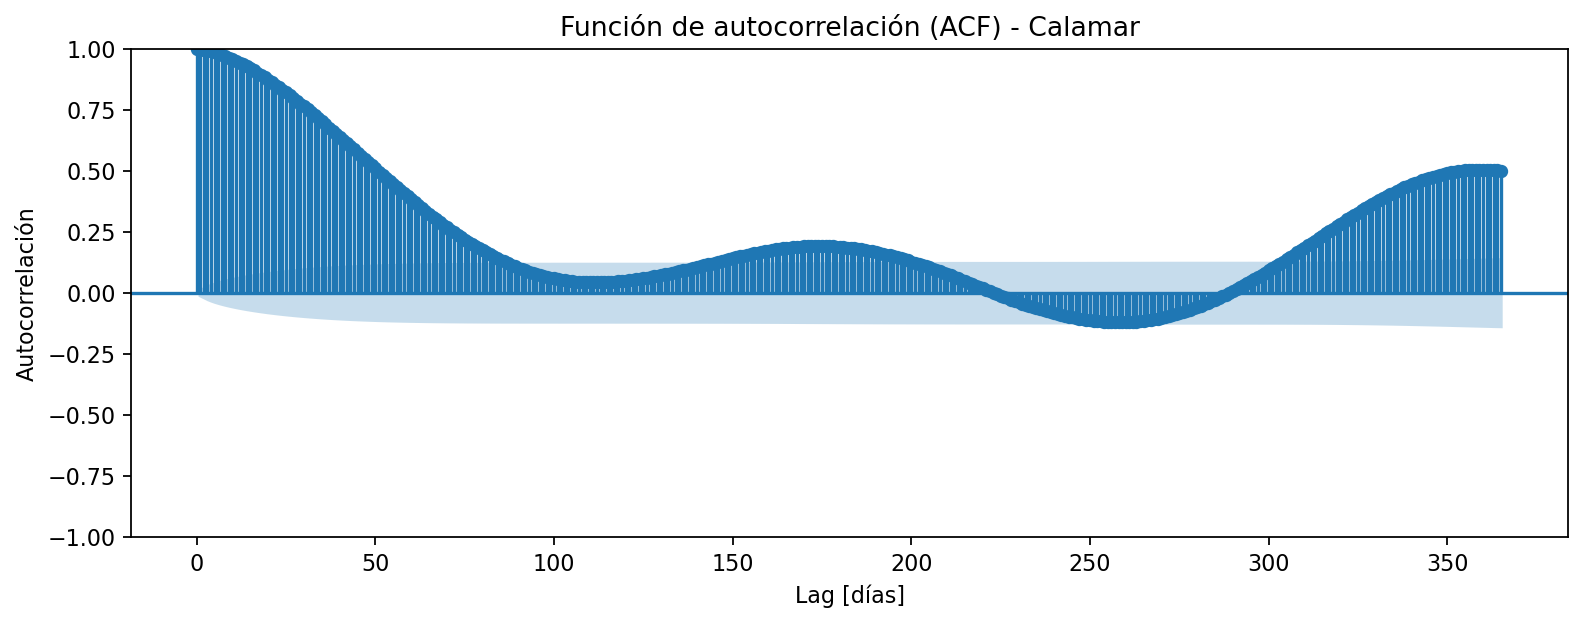

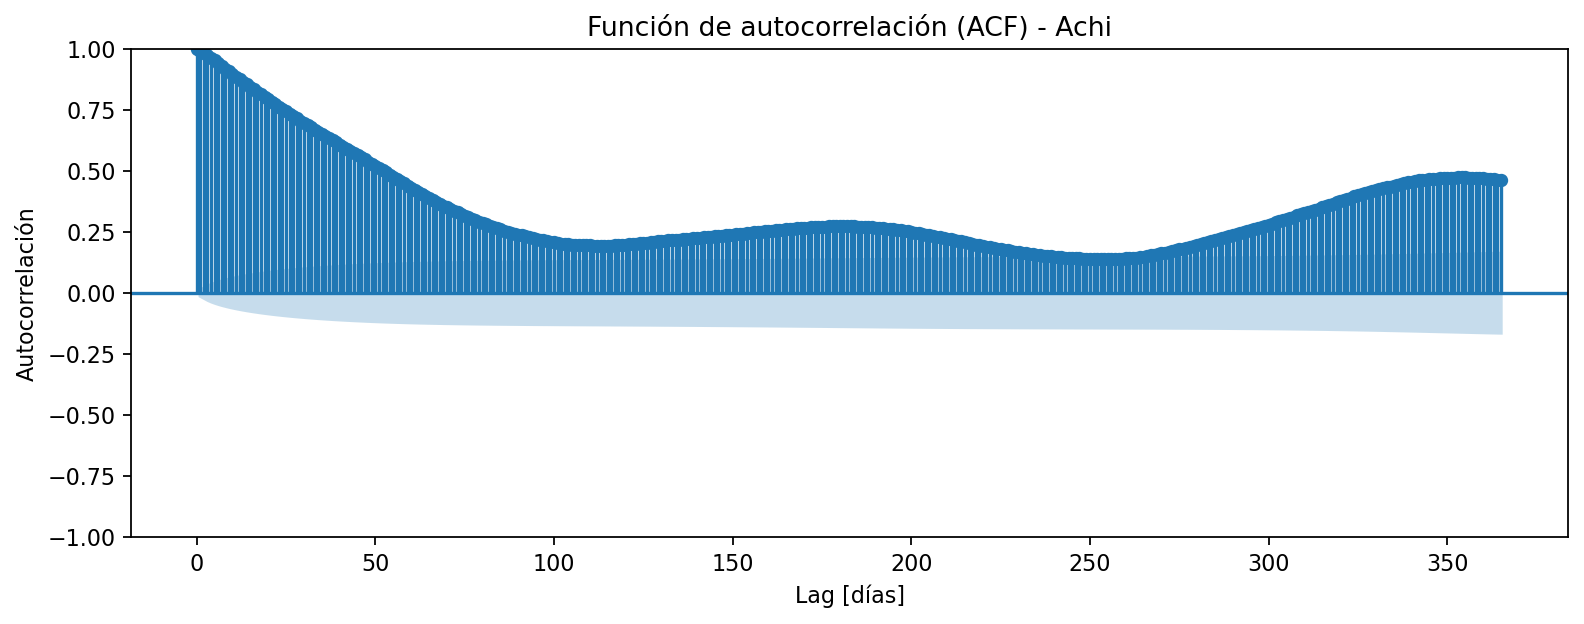

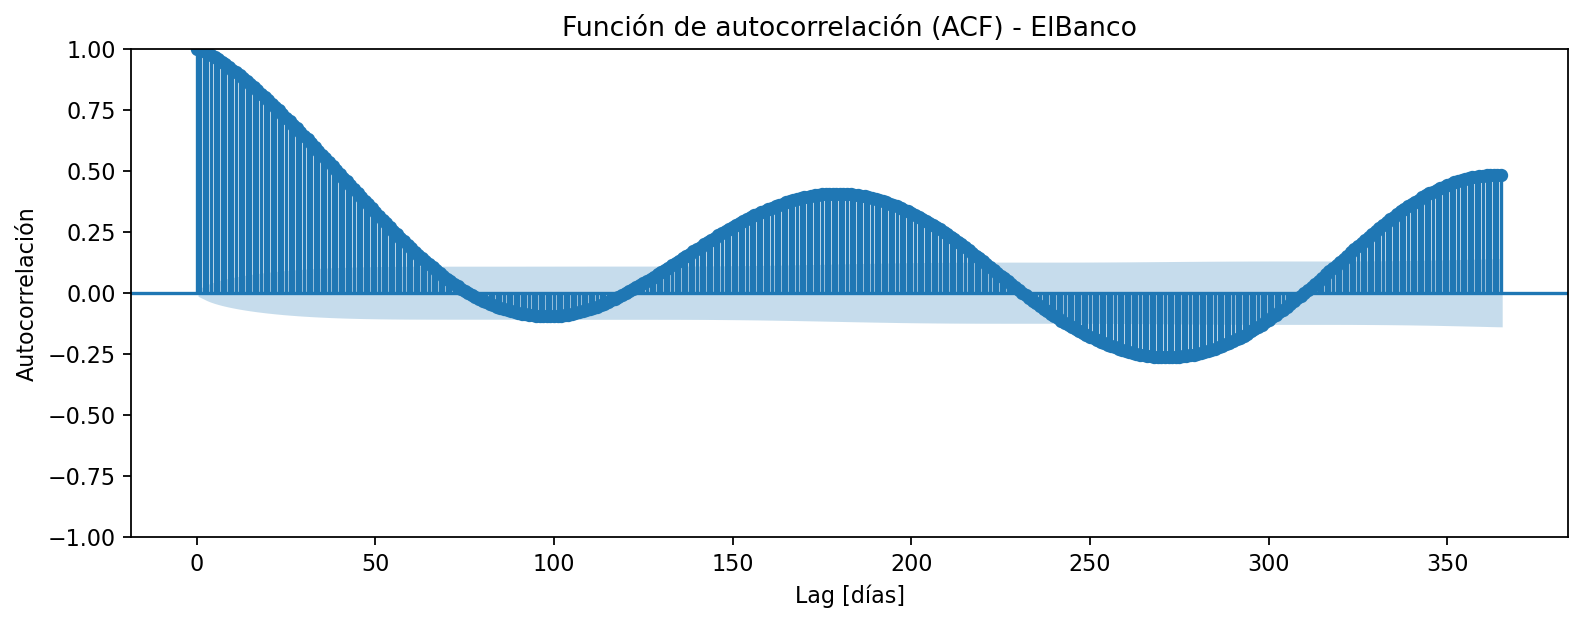

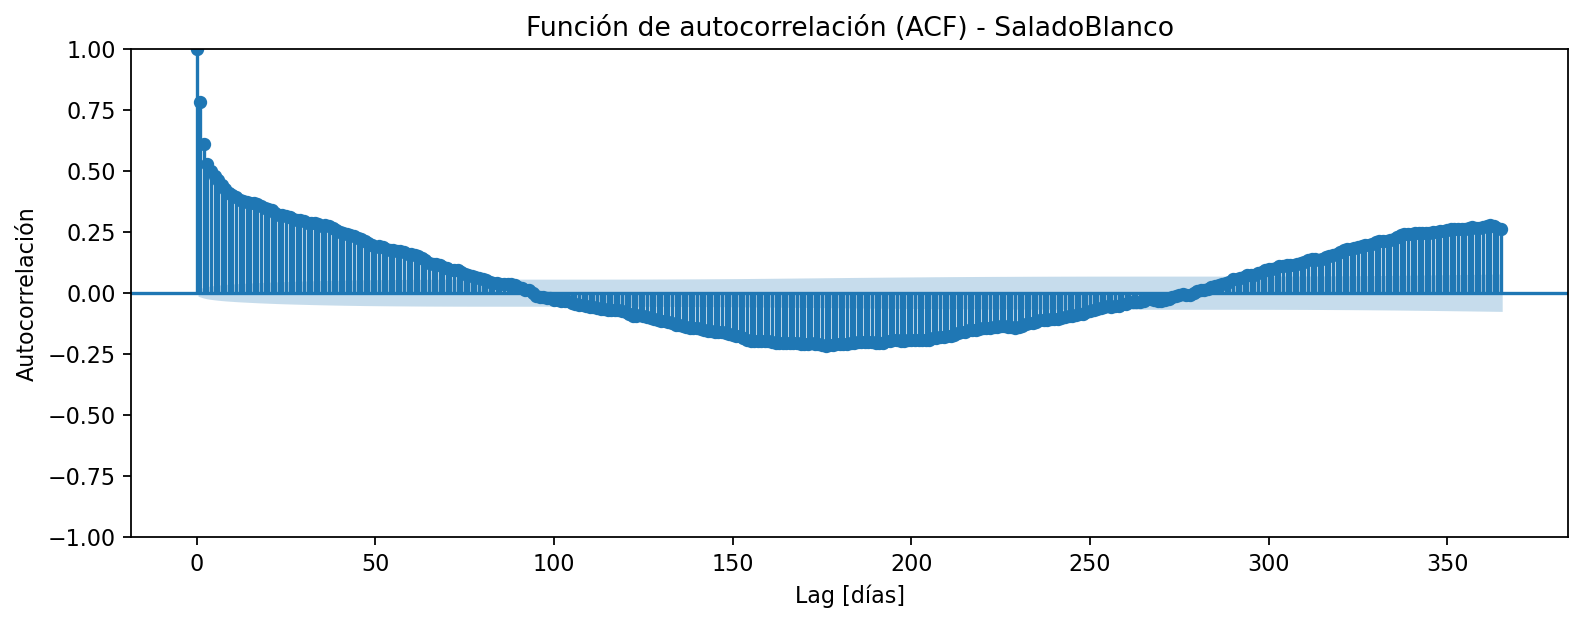

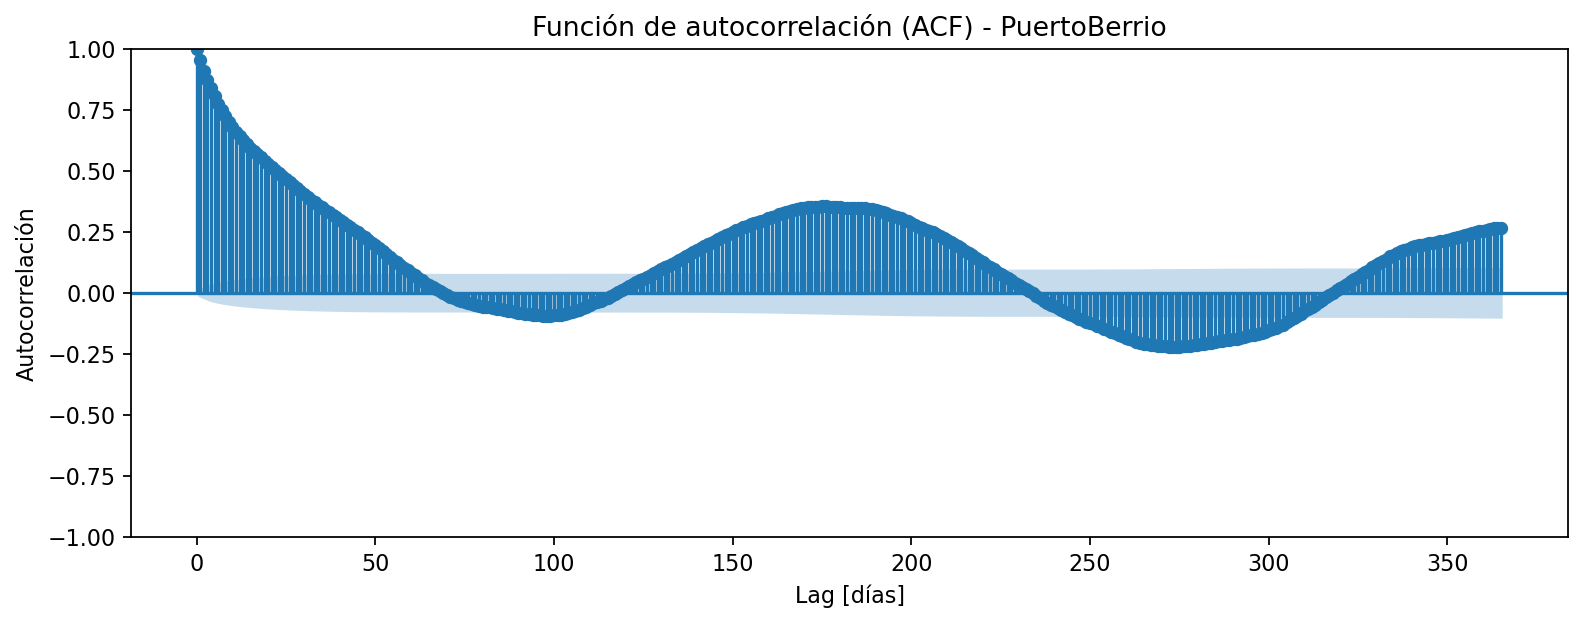

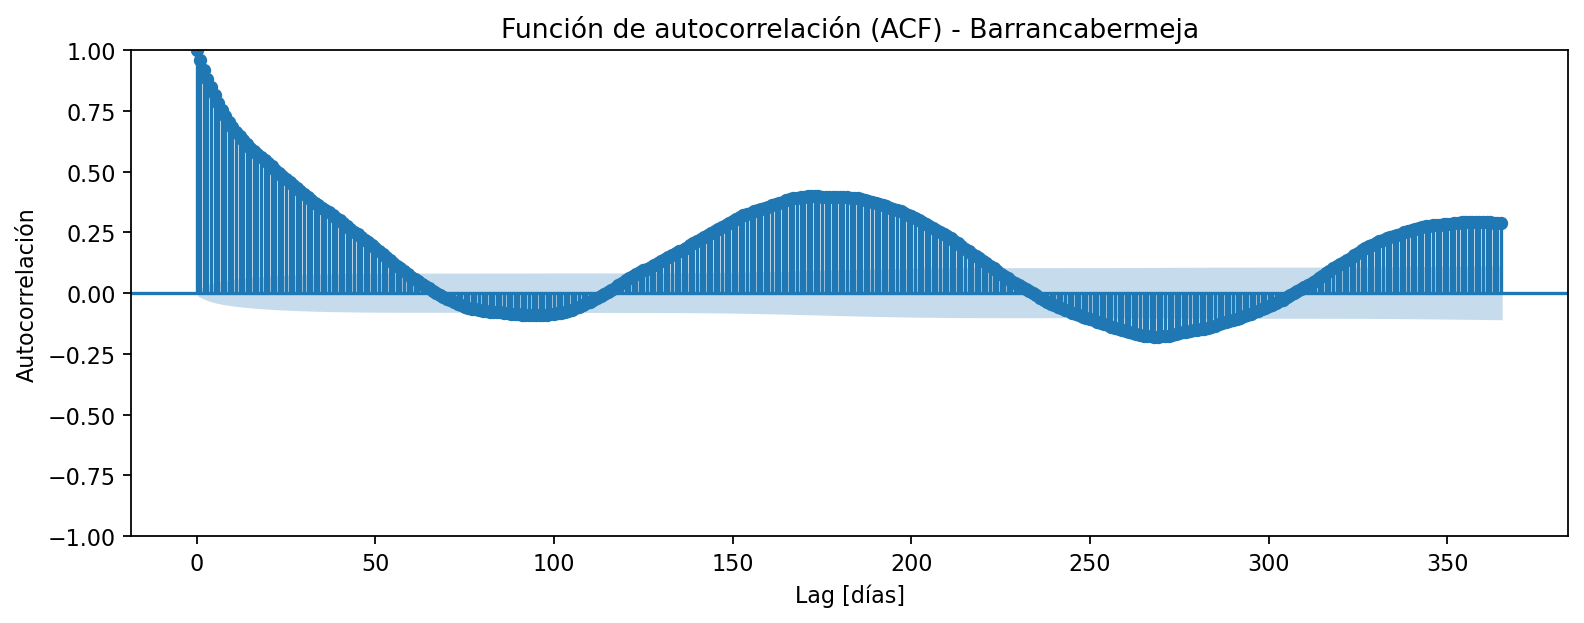

,Serie,Lag,LB_stat,LB_pvalue
0,Calamar,7,125259.23,0.0
1,Calamar,14,241132.28,0.0
2,Calamar,21,343535.48,0.0
3,Calamar,30,452011.30,0.0
4,Calamar,60,636897.02,0.0
5,Calamar,90,667957.45,0.0
6,Calamar,180,693223.51,0.0
7,Calamar,365,895798.36,0.0
8,Achi,7,96728.79,0.0
9,Achi,14,178735.87,0.0


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

ruta = r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\Niveles_alineados.csv"
df = pd.read_csv(ruta, parse_dates=["Fecha"])

series_cols = ["Calamar", "Achi", "ElBanco", "SaladoBlanco", "PuertoBerrio", "Barrancabermeja"]

# Lags de interés para la prueba
lags_test = [7, 14, 21, 30, 60, 90, 180, 365]

resultados_lb = []

for col in series_cols:
    s = df[col].dropna()

    # Gráfica ACF
    fig, ax = plt.subplots(figsize=(10, 4), dpi=160)
    plot_acf(s, lags=365, ax=ax, alpha=0.05)
    ax.set_title(f"Función de autocorrelación (ACF) - {col}")
    ax.set_xlabel("Lag [días]")
    ax.set_ylabel("Autocorrelación")
    plt.tight_layout()
    plt.show()

    # Prueba Ljung-Box
    lb = acorr_ljungbox(s, lags=lags_test, return_df=True)

    for lag, row in lb.iterrows():
        resultados_lb.append({
            "Serie": col,
            "Lag": lag,
            "LB_stat": row["lb_stat"].round(2),
            "LB_pvalue": row["lb_pvalue"]
        })

lb_df = pd.DataFrame(resultados_lb).round(4)
lb_df

En conjunto, los resultados de la prueba de Ljung-Box y de la función de autocorrelación indican que las series de nivel analizadas presentan una dependencia temporal muy marcada y persistente, ya que en todas las estaciones y para todos los rezagos evaluados los valores-p fueron prácticamente nulos, lo que permite rechazar la hipótesis de ausencia de autocorrelación. Se observa en todas las estaciones un comportamiento oscilatorio, lo que sugiere no solo memoria temporal fuerte, sino también la presencia de una componente estacional anual bien definida.

## 5.2. Box Plots mensuales

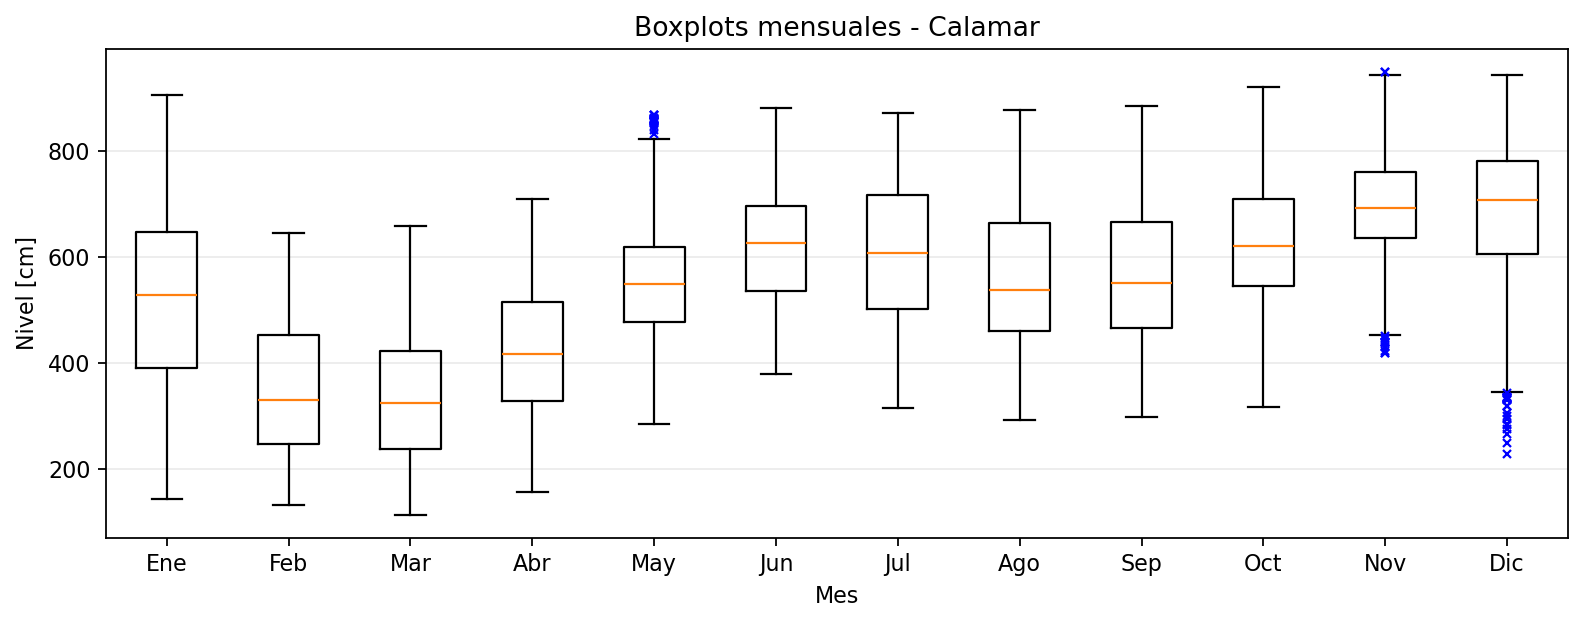

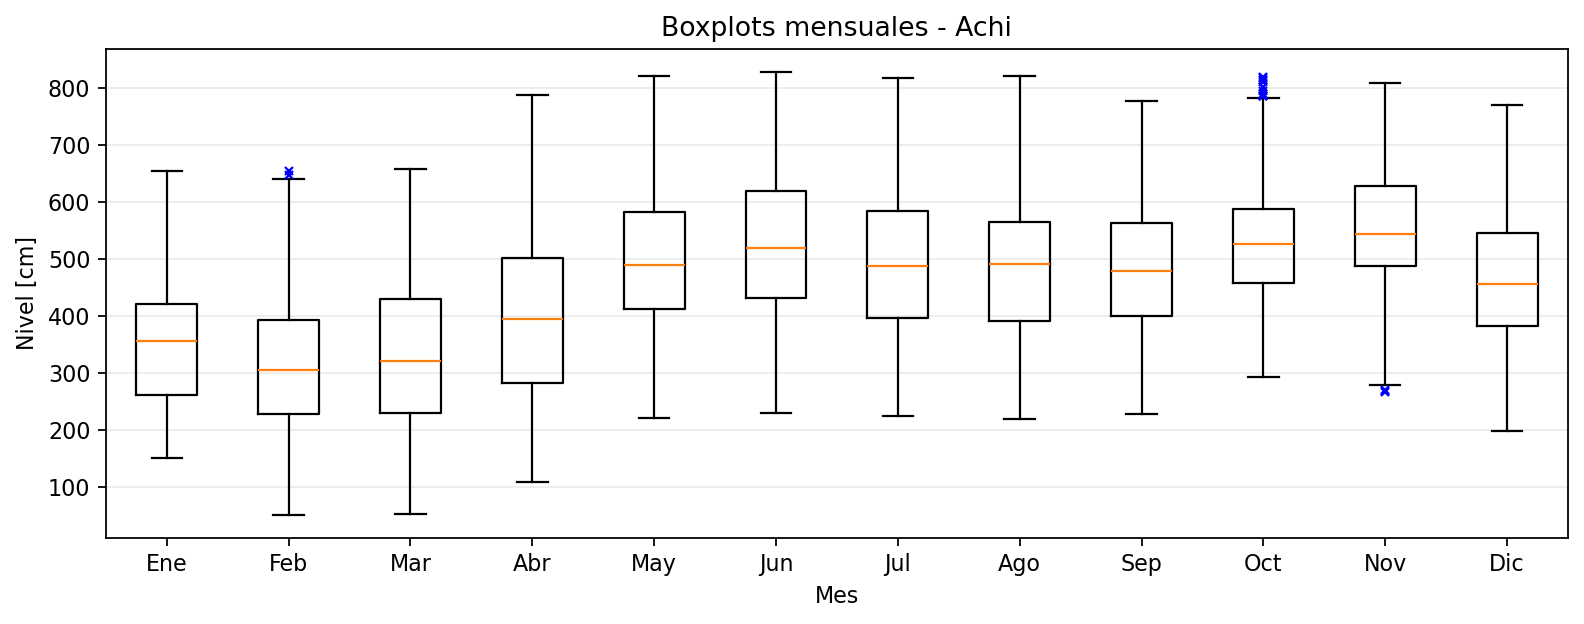

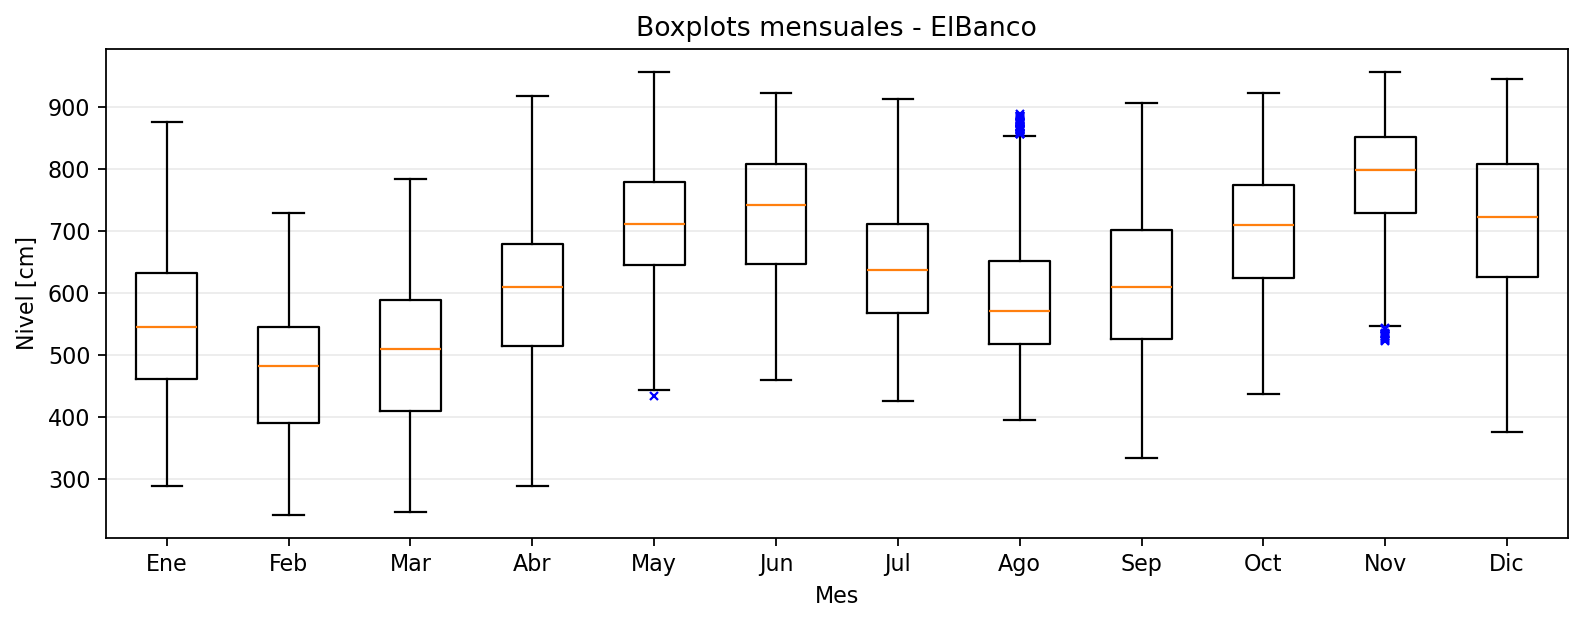

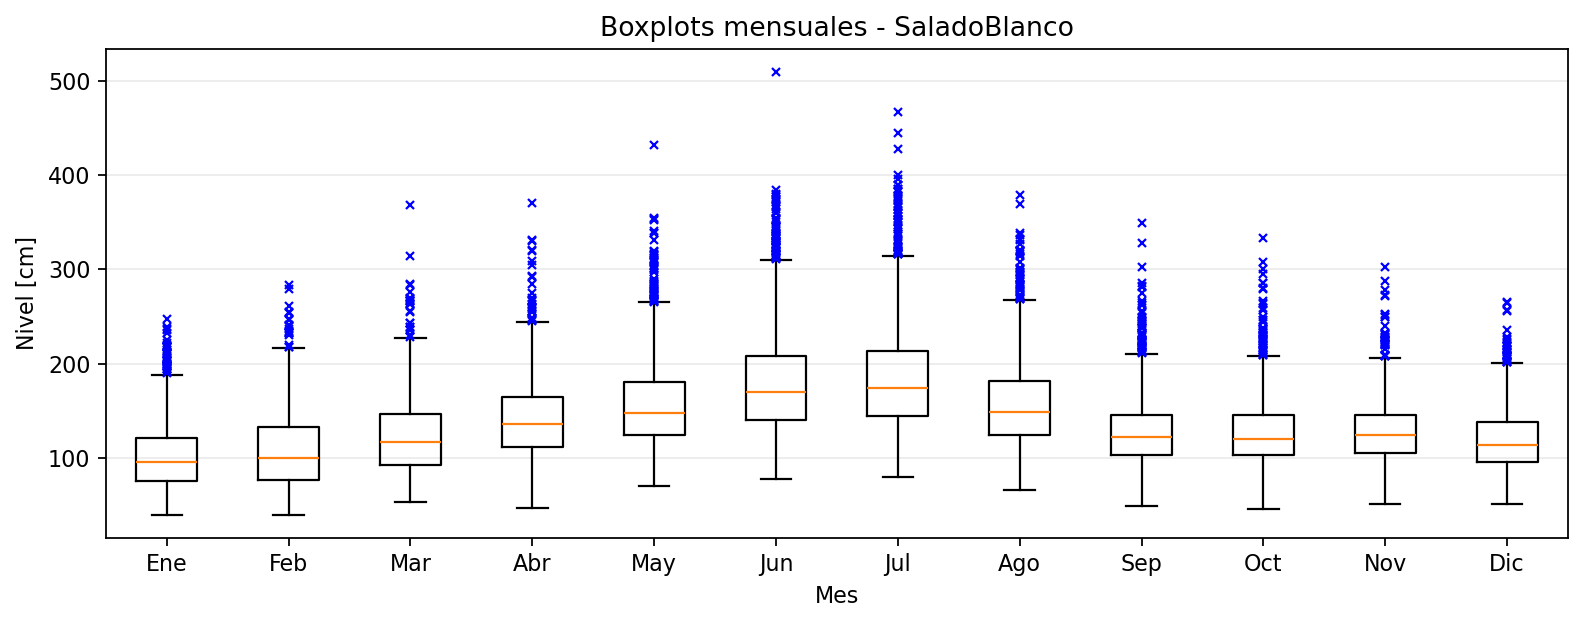

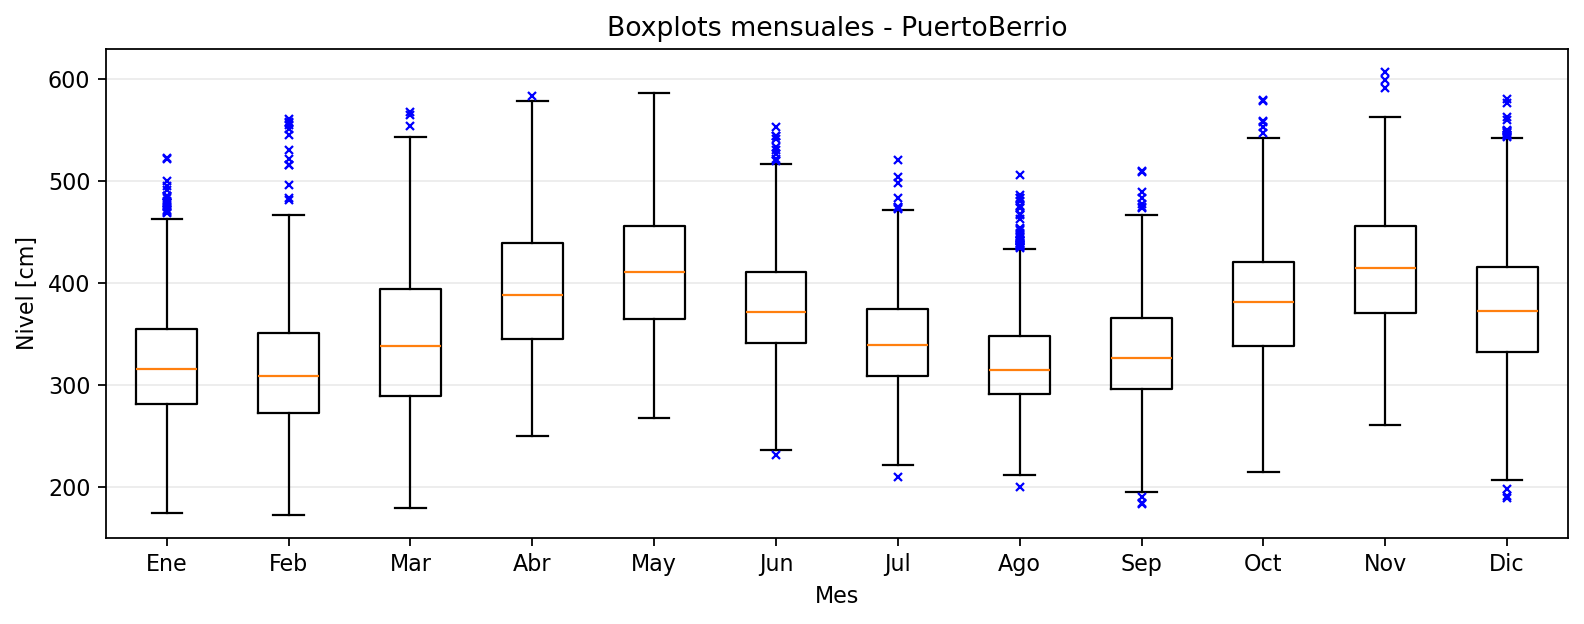

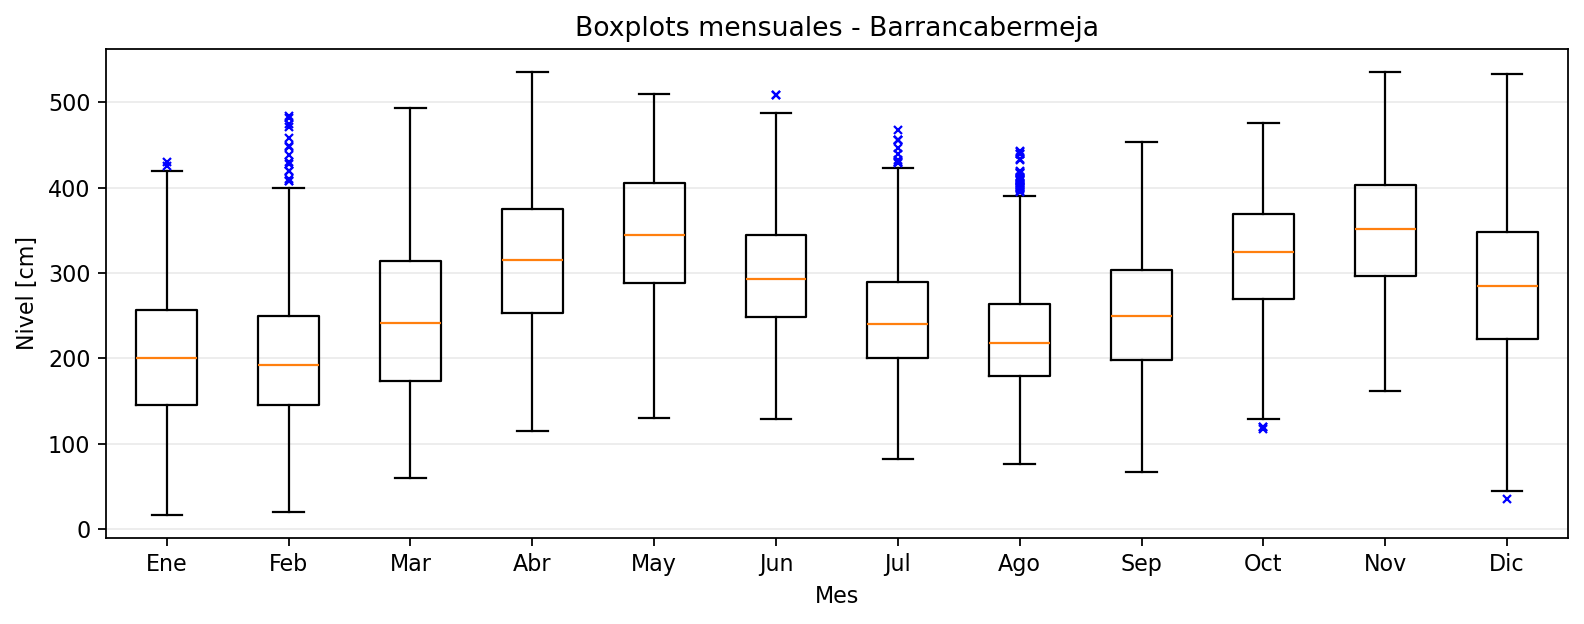

In [2]:
df_mes = df.copy()
df_mes["Mes"] = df_mes["Fecha"].dt.month

mes_labels = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
              "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

for col in series_cols:
    fig, ax = plt.subplots(figsize=(10, 4), dpi=160)

    data_mes = [df_mes.loc[df_mes["Mes"] == m, col].dropna() for m in range(1, 13)]

    ax.boxplot(
        data_mes,
        tick_labels=mes_labels,
        flierprops=dict(
            marker='x',
            markeredgecolor='blue',
            markersize=4,
            linestyle='none'
        )
    )

    ax.set_title(f"Boxplots mensuales - {col}")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Nivel [cm]")
    ax.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


## 5.3. Tendencias

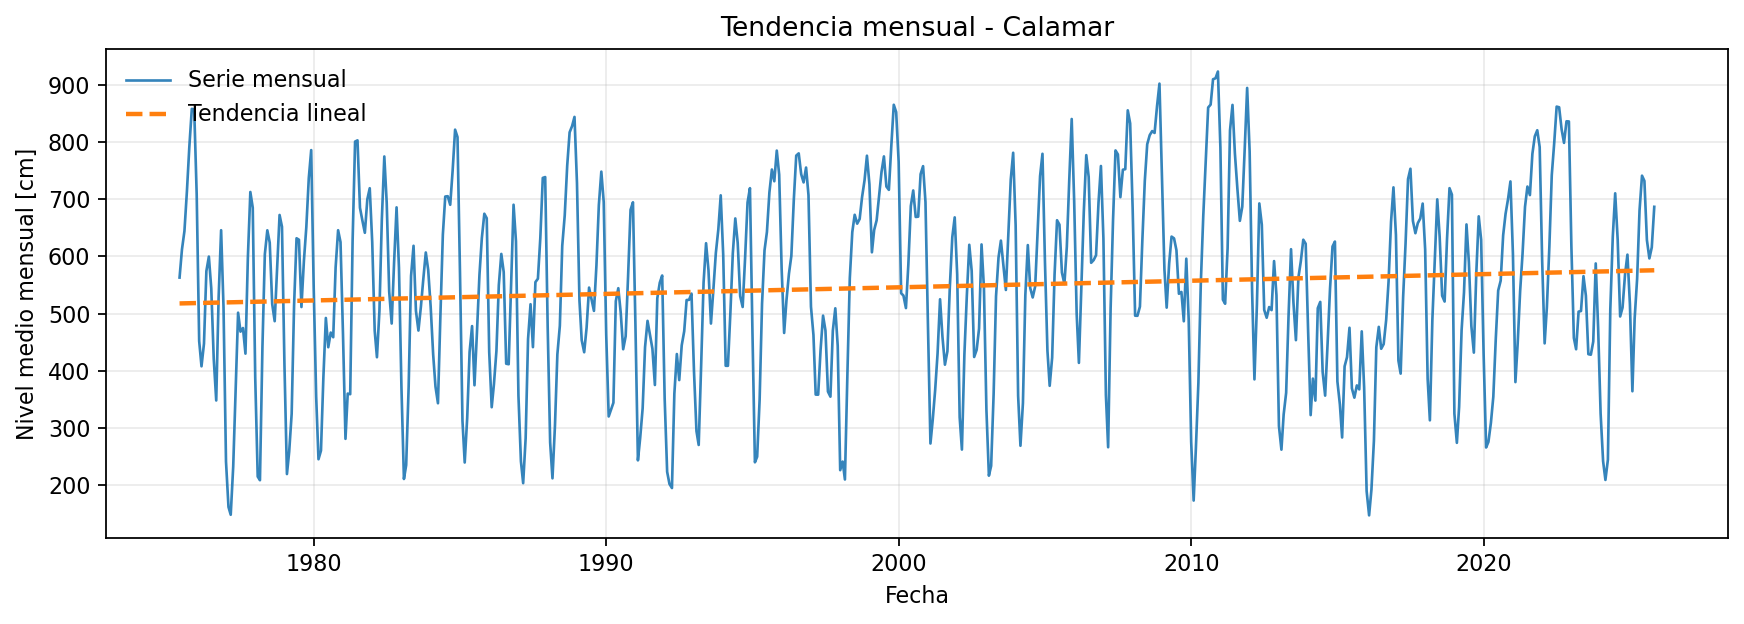

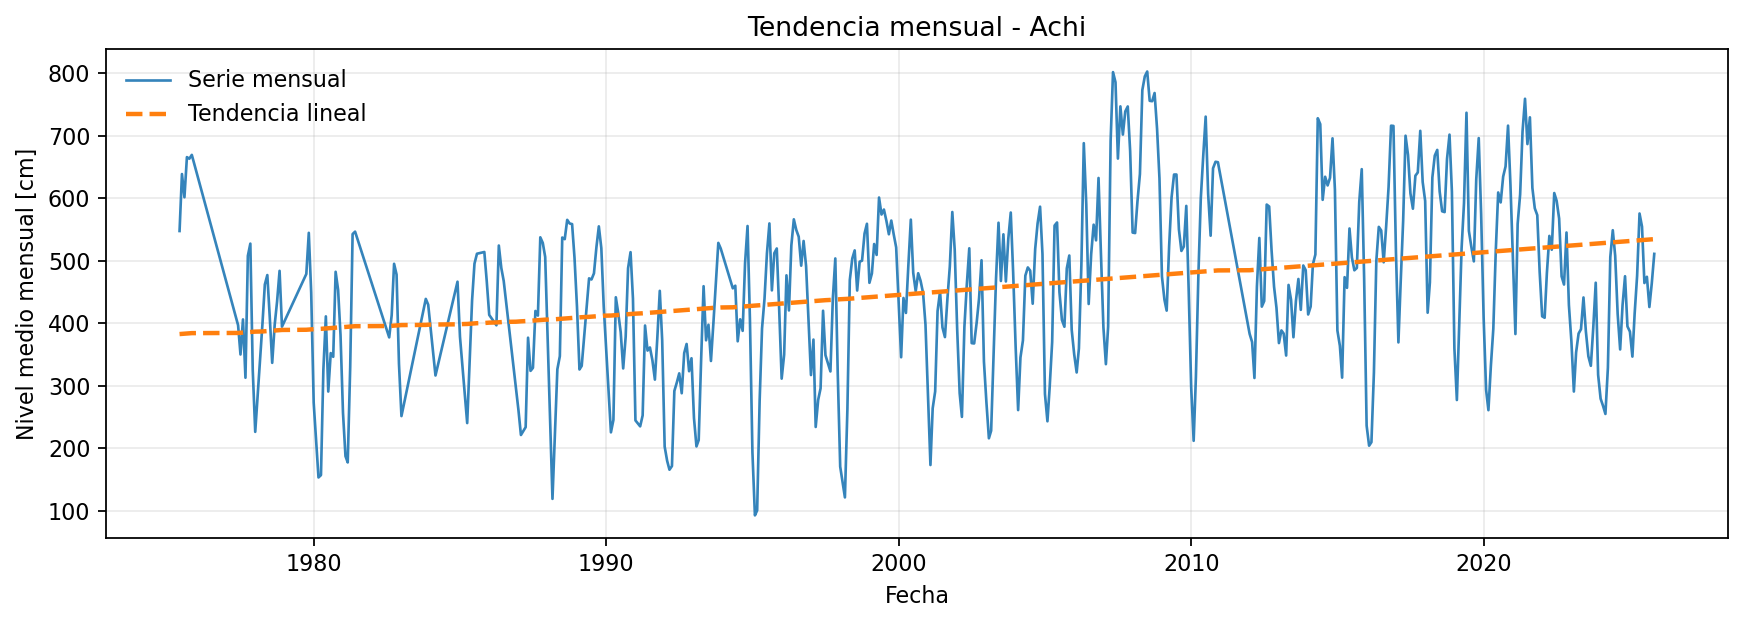

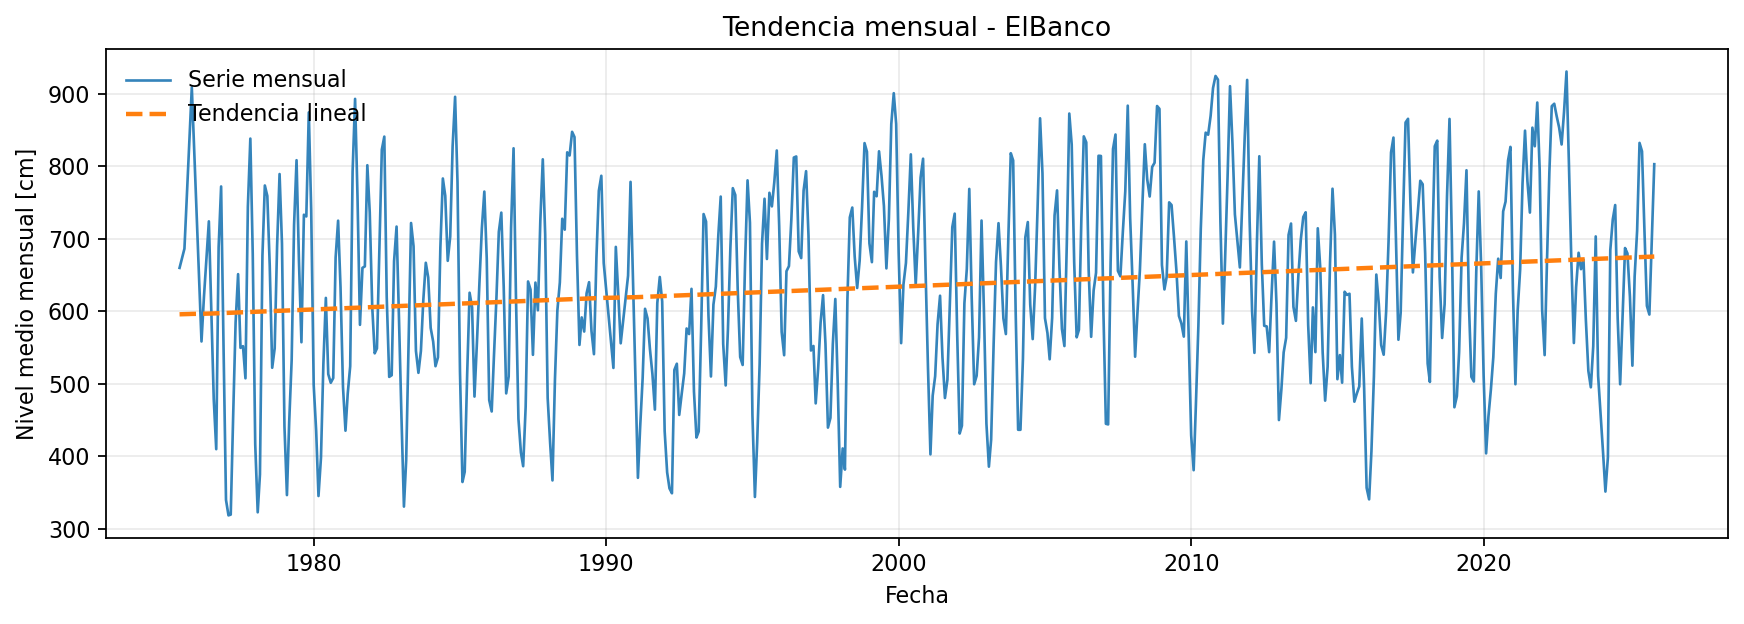

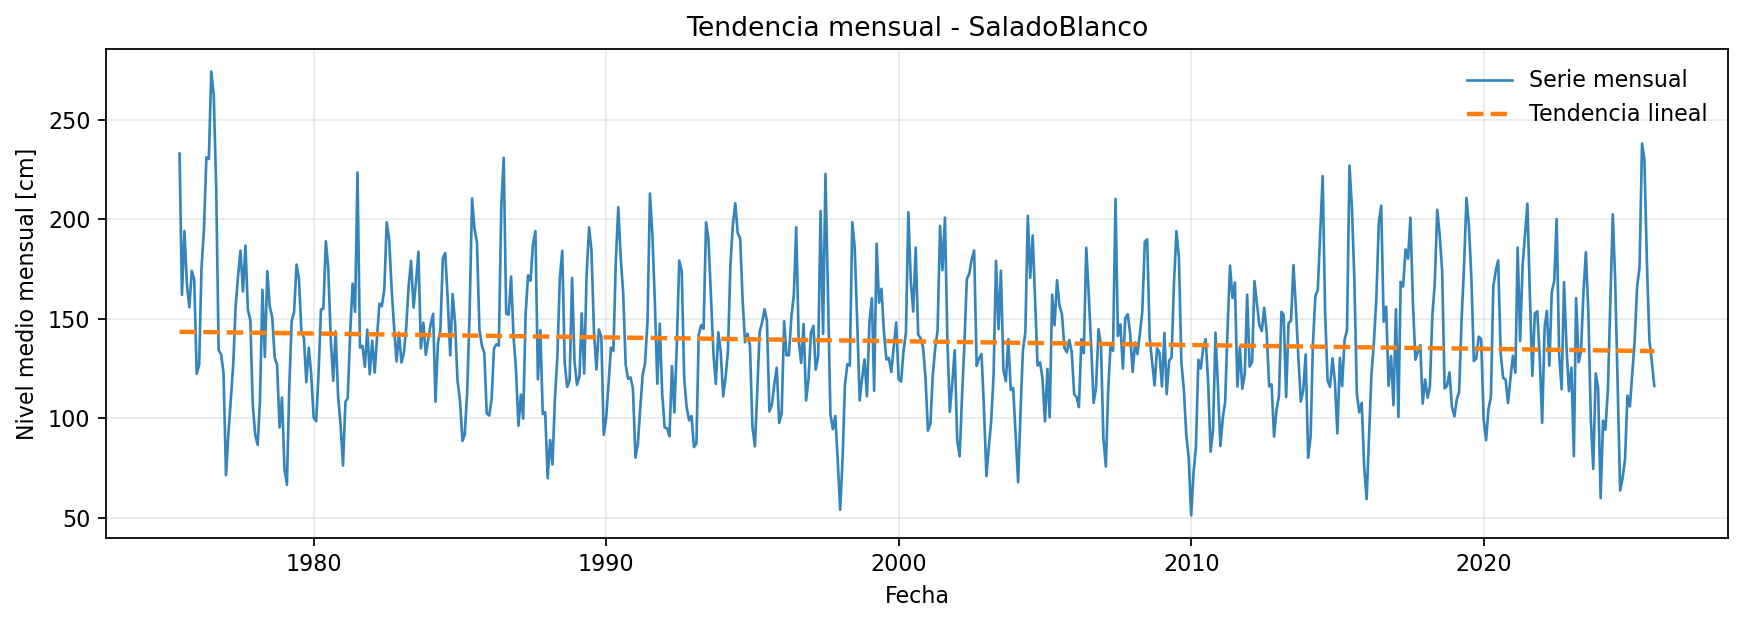

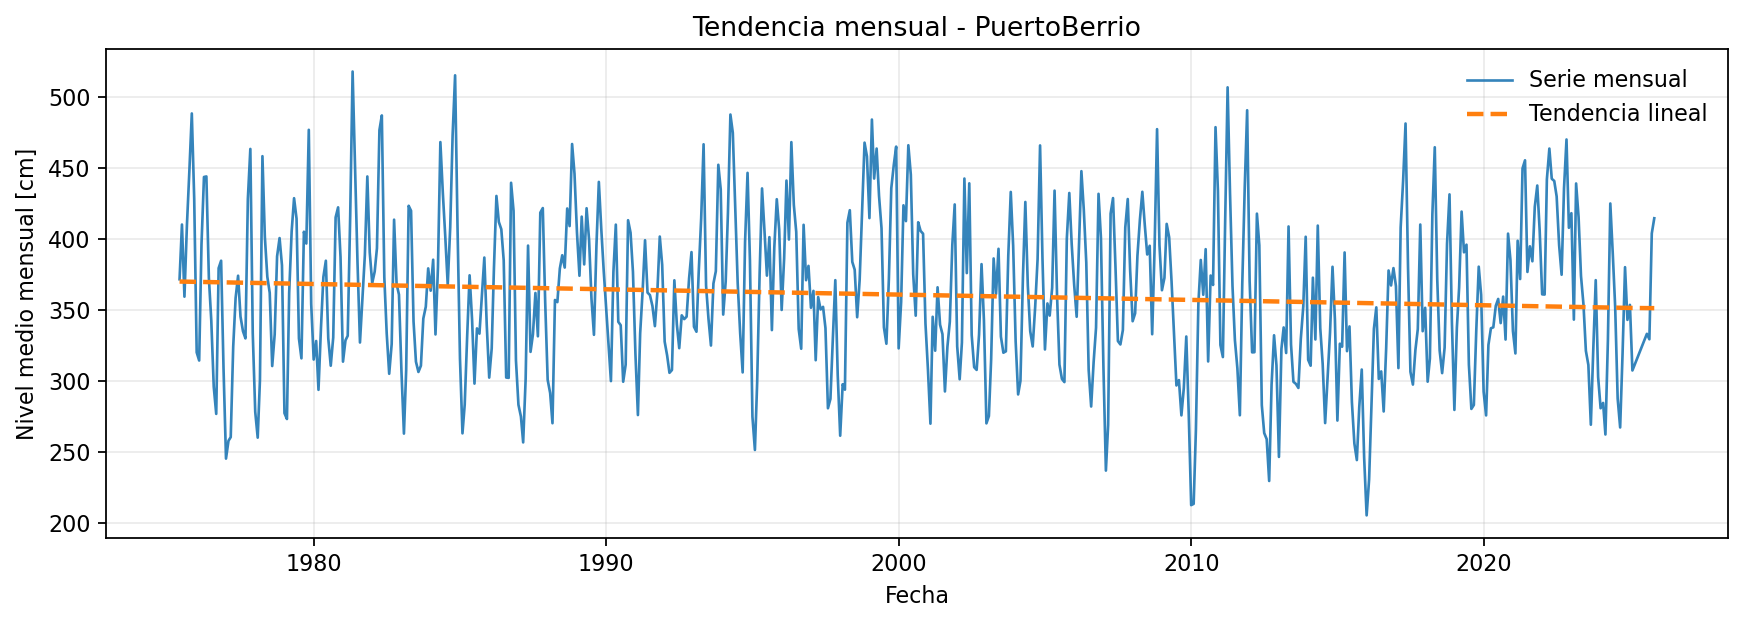

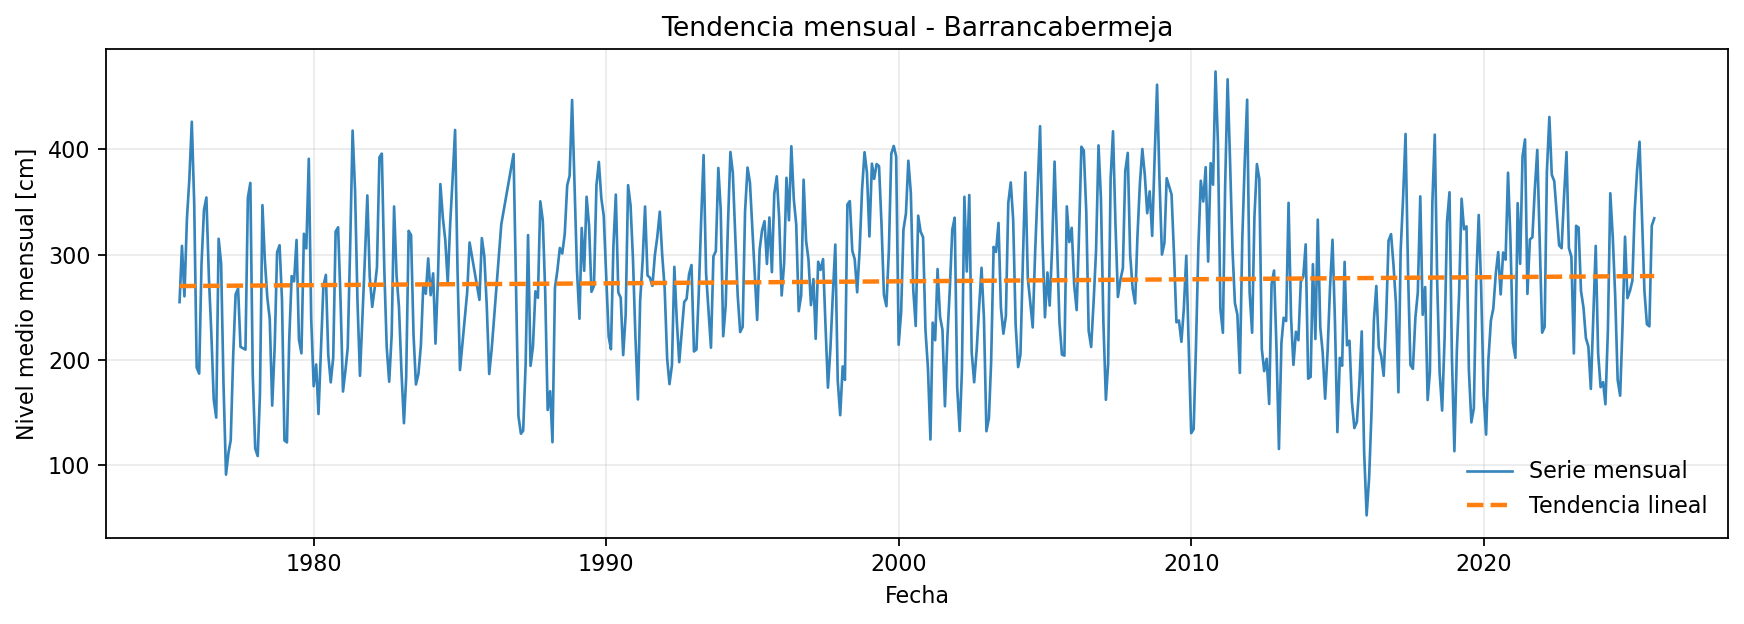

,Serie,Trend,p_value,Tau,Slope,Intercept
0,Calamar,increasing,0.0001,0.1101,1.5246,508.9144
1,Achi,increasing,0.0000,0.2188,3.2714,395.3765
2,ElBanco,increasing,0.0000,0.1474,1.7747,595.8188
3,SaladoBlanco,decreasing,0.0137,-0.0692,-0.1721,139.8315
4,PuertoBerrio,decreasing,0.0064,-0.0770,-0.4895,372.3856
5,Barrancabermeja,no trend,0.4090,0.0236,0.1857,270.9632


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

# Series
series_cols = ["Calamar", "Achi", "ElBanco", "SaladoBlanco", "PuertoBerrio", "Barrancabermeja"]

df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
df = df.sort_values("Fecha").reset_index(drop=True)

# Promedios mensuales
df_m = df.copy()
df_m["AñoMes"] = df_m["Fecha"].dt.to_period("M")

df_monthly = (
    df_m.groupby("AñoMes")[series_cols]
        .mean()
        .reset_index()
)

df_monthly["Fecha"] = df_monthly["AñoMes"].dt.to_timestamp()

# Tendencia lineal y test Mann-Kendall
resultados = []

for col in series_cols:
    s = df_monthly[["Fecha", col]].dropna().copy()

    # Tendencia lineal 
    x = np.arange(len(s))
    y = s[col].values
    coef = np.polyfit(x, y, 1)
    trend_line = np.poly1d(coef)(x)

    # Seasonal Mann-Kendall mensual
    res = mk.seasonal_test(s[col], period=12)

    resultados.append({
        "Serie": col,
        "Trend": res.trend,
        "p_value": res.p,
        "Tau": res.Tau,
        "Slope": res.slope,
        "Intercept": res.intercept
    })

    # Gráfica
    fig, ax = plt.subplots(figsize=(11, 4), dpi=160)
    ax.plot(s["Fecha"], s[col], lw=1.2, alpha=0.9, label="Serie mensual")
    ax.plot(s["Fecha"], trend_line, lw=2.0, linestyle="--", label="Tendencia lineal")
    ax.set_title(f"Tendencia mensual - {col}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Nivel medio mensual [cm]")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# Resultados
mk_df = pd.DataFrame(resultados).round(4)
display(mk_df)

Dado que las series presentaron autocorrelación significativa, la tendencia se evaluó mediante la prueba Seasonal Mann-Kendall sobre series mensuales agregadas, en lugar de aplicar una prueba simple sobre los datos diarios. Los resultados muestran una tendencia creciente significativa en Calamar, Achí y El Banco, así como una tendencia decreciente significativa en Salado Blanco y Puerto Berrío. En contraste, Barrancabermeja no presentó una tendencia estadísticamente significativa, por lo que no se encontró evidencia suficiente de un cambio monotónico sostenido en esa estación.